# HSI Spatial Calibration


## Import Libraries


In [5]:
import os
import sys
import math
import numpy as np
import pandas as pd
import spectral
from IPython.core import ultratb
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, Point
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score

# Enable support for ENVI header files with non-lowercase parameter names
spectral.settings.envi_support_nonlowercase_params = True

## Read HSI


In [6]:
def read_hsi(hdr_file):
    """
    Read a hyperspectral image and return the image and its wavelengths
    """
    image = spectral.open_image(hdr_file).load()
    wavelengths = [float(w) for w in image.metadata["Wavelength"]]

    return image, wavelengths

## Mean Intensity


In [7]:
def plot_mean_spectrum(image):
    """
    Calculate the mean intensity across each band of a hyperspectral image and plot it
    """
    # Check if image is a 3D array
    if len(image.shape) != 3:
        raise ValueError("Expected a 3D hyperspectral image array")

    # Calculate mean intensity across spatial dimensions for each band
    mean_intensities = np.mean(image, axis=(0, 1))

    # Calculate standard deviation across spatial dimensions for each band
    std_intensities = np.std(image, axis=(0, 1))

    # Create the pixel index
    index = range(len(mean_intensities))

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot the mean intensity line
    plt.plot(index, mean_intensities, "b-", label="Mean")

    # Plot the standard deviation region
    plt.fill_between(
        index,
        mean_intensities - std_intensities,
        mean_intensities + std_intensities,
        color="b",
        alpha=0.2,
        label="±1σ",
    )

    plt.xlabel("Pixel Location")
    plt.ylabel("Mean Intensity")
    plt.grid(True)
    plt.legend()

    # Add band count and wavelength range information
    plt.annotate(
        f"Bands: {len(index)}",
        xy=(0.05, 0.9),
        xycoords="axes fraction",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
    )

    plt.show()

    return mean_intensities

## Identify Spectral Peaks


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pathlib import Path

def find_spectral_peaks(
    spectrum,
    wavelengths,
    height_ratio=0.05,
    prominence_ratio=0.03,
    distance=2,
    save_path="../figures/spectral_peaks.svg",
    show=True,
):
    """
    Detect spectral peaks and save a vector SVG plot.

    Common reasons SVG wasn't saved before:
      1) Calling plt.show() BEFORE savefig (some backends clear/close the figure).
      2) Output directory doesn't exist.
      3) Saving without referencing the current figure handle.
    This version fixes all three.
    """
    # --- Prepare data ---
    spectrum = np.asarray(spectrum, dtype=float)
    wavelengths = np.asarray(wavelengths, dtype=float)
    if spectrum.ndim != 1 or wavelengths.ndim != 1 or spectrum.size != wavelengths.size:
        raise ValueError("spectrum and wavelengths must be 1D arrays of the same length.")

    # --- Thresholds ---
    max_intensity = float(np.max(spectrum))
    min_height = max_intensity * float(height_ratio)
    min_prominence = max_intensity * float(prominence_ratio)

    # --- Peak detection ---
    peak_indices, properties = find_peaks(
        spectrum, height=min_height, prominence=min_prominence, distance=distance
    )
    peak_wavelengths = wavelengths[peak_indices]
    peak_intensities = spectrum[peak_indices]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(np.arange(len(wavelengths)), spectrum, "g-", label="Spectrum")
    ax.plot(peak_indices, peak_intensities, "ro", label="Peaks")

    ax.set_xlim(0, 1000)

    # for wl, inten, idx in zip(peak_wavelengths, peak_intensities, peak_indices):
    #     ax.annotate(
    #         f"{idx}",
    #         xy=(wl, inten),
    #         xytext=(0, 6),
    #         textcoords="offset points",
    #         ha="center",
    #         fontsize=9,
    #         color="red",
    #     )

    # --- Bold and large labels ---
    ax.set_xlabel("Pixel Location", fontsize=18, fontweight="bold")
    ax.set_ylabel("Intensity (a.u.)", fontsize=18, fontweight="bold")
    

    # --- Make tick labels larger ---
    ax.tick_params(axis="both", labelsize=15, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=15)
    fig.tight_layout()

    # --- Ensure output dir and SAVE BEFORE show() ---
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, format="svg")  # dpi is irrelevant for vector elements

    if show:
        plt.show()
    else:
        plt.close(fig)

    # --- Return info ---
    return {
        "peak_indices": peak_indices,
        "peak_wavelengths": peak_wavelengths,
        "peak_intensities": peak_intensities,
        "svg_path": str(save_path),
    }

## Calibration Spectral Bands


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

def calibrate_spectral_bands_multi(
    sources: dict,
    total_bands: int | None = None,
    polynomial_order: int = 3,
    save_path: str = "../figures/spectral_calibration.svg",
    annotate: bool = True,
    show: bool = True,
    colors: dict | None = None,
):
    """
    Fit a wavelength calibration polynomial using reference lines from multiple light sources
    and plot the calibration curve with per-source colored points and residuals.

    Parameters
    ----------
    sources : dict
        Mapping {source_name: {band_number: wavelength_nm, ...}, ...}
        e.g., {"Kr": {575: 760.15, ...}, "Xe": {...}, "Hg": {...}}
    total_bands : int | None
        Number of bands to evaluate the fitted polynomial on (x = [0..total_bands-1]).
        If None, uses max observed band + 1.
    polynomial_order : int
        Polynomial order for np.polyfit (e.g., 2, 3, 4).
    save_path : str
        File path to save the SVG figure.
    annotate : bool
        If True, annotate each reference point with its wavelength.
    show : bool
        If True, display the plot window.
    colors : dict | None
        Optional mapping {source_name: matplotlib_color}. If None, an internal palette is used.

    Returns
    -------
    dict
        {
          "coefficients": np.ndarray,
          "polynomial": np.poly1d,
          "calibrated_wavelengths": np.ndarray,   # length = total_bands
          "rmse": float,
          "r_squared": float,
          "residuals": np.ndarray,                # per-point residuals aligned with input order
          "per_source": {
              source_name: {
                  "bands": np.ndarray,
                  "wavelengths": np.ndarray,
                  "residuals": np.ndarray
              }, ...
          }
        }
    """
    # -------- Gather & sort combined data --------
    all_bands = []
    all_wls = []
    all_labels = []

    # Preserve a consistent per-source order (sorted by band)
    for src, lines in sources.items():
        for b, wl in sorted(lines.items(), key=lambda kv: kv[0]):
            all_bands.append(float(b))
            all_wls.append(float(wl))
            all_labels.append(src)

    all_bands = np.asarray(all_bands, dtype=float)
    all_wls = np.asarray(all_wls, dtype=float)

    sort_idx = np.argsort(all_bands)
    all_bands = all_bands[sort_idx]
    all_wls = all_wls[sort_idx]
    all_labels = [all_labels[i] for i in sort_idx]

    if total_bands is None:
        total_bands = int(np.max(all_bands)) + 1

    # -------- Fit polynomial --------
    coefficients = np.polyfit(all_bands, all_wls, polynomial_order)
    poly = np.poly1d(coefficients)

    pred_wls = poly(all_bands)
    residuals = all_wls - pred_wls
    rmse = float(np.sqrt(np.mean(residuals**2)))
    r_squared = float(r2_score(all_wls, pred_wls))

    band_range = np.arange(total_bands, dtype=float)
    calibrated_wavelengths = poly(band_range)

    # -------- Plotting --------
    # Default color cycle if not provided
    if colors is None:
        palette = [
            "tab:red", "tab:blue", "tab:green", "tab:orange",
            "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"
        ]
        unique_sources = list(sources.keys())
        colors = {src: palette[i % len(palette)] for i, src in enumerate(unique_sources)}

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [3, 1]}
    )

    # Calibration curve
    ax1.plot(band_range, calibrated_wavelengths, "-", lw=2, label="Calibration Curve")

    # Scatter per source (colored)
    for src, lines in sources.items():
        # Select the points belonging to this source (after global sort)
        idx = [i for i, lab in enumerate(all_labels) if lab == src]
        if not idx:
            continue
        b_src = all_bands[idx]
        wl_src = all_wls[idx]

        ax1.scatter(b_src, wl_src, s=80, color=colors[src], edgecolor="black", linewidths=0.6, label=src)

        if annotate:
            for b, wl in zip(b_src, wl_src):
                ax1.annotate(
                    f"{wl:.2f} nm",
                    xy=(b, wl),
                    xytext=(6, 6),
                    textcoords="offset points",
                    fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="w", alpha=0.7),
                )

    ax1.set_xlabel("Band Number")
    ax1.set_ylabel("Wavelength (nm)")
    ax1.set_title(f"Spectral Calibration (Order {polynomial_order})\n"
                  f"R²={r_squared:.4f}, RMSE={rmse:.3f} nm")
    ax1.grid(True, alpha=0.3)
    ax1.legend(ncols=min(3, len(sources) + 1), frameon=True)

    # Residuals (per source, same colors)
    for src in sources.keys():
        idx = np.array([i for i, lab in enumerate(all_labels) if lab == src], dtype=int)
        if idx.size == 0:
            continue
        ax2.scatter(all_bands[idx], residuals[idx], s=60, color=colors[src], edgecolor="black", linewidths=0.5, label=src)

    ax2.axhline(0, color="k", linestyle="--", alpha=0.4)
    ax2.set_xlabel("Band Number")
    ax2.set_ylabel("Residual (nm)")
    ax2.set_title("Calibration Residuals")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save & show
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300)
    if show:
        plt.show()
    else:
        plt.close(fig)

    # -------- Per-source breakdown --------
    per_source = {}
    for src in sources.keys():
        idx = np.array([i for i, lab in enumerate(all_labels) if lab == src], dtype=int)
        per_source[src] = {
            "bands": all_bands[idx],
            "wavelengths": all_wls[idx],
            "residuals": residuals[idx],
        }

    # Print polynomial (descending powers)
    print("\nCalibration Polynomial Coefficients (descending powers):")
    for i, c in enumerate(coefficients):
        print(f"a{len(coefficients)-1-i} = {c:.8e}")

    print(f"\nCalibration Equation:\n  λ̂(band) = {poly}")
    print(f"Global R²: {r_squared:.4f}")
    print(f"Global RMSE: {rmse:.4f} nm")

    return {
        "coefficients": coefficients,
        "polynomial": poly,
        "calibrated_wavelengths": calibrated_wavelengths,
        "rmse": rmse,
        "r_squared": r_squared,
        "residuals": residuals,
        "per_source": per_source,
    }

In [10]:
def compare_wavelength_calibrations(
    original_wavelengths, calibrated_wavelengths, mark_bands=[]
):
    """
    Compare original and calibrated wavelengths by plotting both on the same graph
    and showing their differences.
    """
    # Convert inputs to numpy arrays
    original_wavelengths = np.array(original_wavelengths)
    calibrated_wavelengths = np.array(calibrated_wavelengths)

    # Create band numbers
    band_numbers = np.arange(len(original_wavelengths))

    # Calculate difference between calibrations
    wavelength_difference = calibrated_wavelengths - original_wavelengths

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [2, 1]}
    )

    # Plot both wavelength calibrations
    ax1.plot(
        band_numbers,
        original_wavelengths,
        "b-",
        label="Original Wavelengths",
        linewidth=2,
    )
    ax1.plot(
        band_numbers,
        calibrated_wavelengths,
        "r-",
        label="Calibrated Wavelengths",
        linewidth=2,
    )

    # Add markers at specific intervals for better visualization
    ax1.plot(
        mark_bands,
        original_wavelengths[mark_bands],
        "bo",
        markersize=6,
    )
    ax1.plot(
        mark_bands,
        calibrated_wavelengths[mark_bands],
        "ro",
        markersize=6,
    )

    ax1.set_xlabel("Band Number")
    ax1.set_ylabel("Wavelength (nm)")
    ax1.set_title("Comparison of Original and Calibrated Wavelengths")
    ax1.grid(True)
    ax1.legend()

    # Annotate the mark points for reference
    for idx in mark_bands:
        band = band_numbers[idx]
        orig_wl = original_wavelengths[idx]
        cal_wl = calibrated_wavelengths[idx]

        # Add annotations
        ax1.annotate(
            f"Band {band}, Orig: {orig_wl:.2f}, Cal: {cal_wl:.2f}",
            xy=(band, cal_wl),
            xytext=(15, -10),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"),
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7),
            fontsize=8,
        )

    # Plot the difference
    ax2.plot(band_numbers, wavelength_difference, "g-", linewidth=2)
    ax2.plot(band_numbers, wavelength_difference, "go", markersize=4)
    ax2.axhline(y=0, color="r", linestyle="--", linewidth=1)

    # Add shaded area for context
    ax2.fill_between(
        band_numbers,
        wavelength_difference,
        0,
        where=(wavelength_difference >= 0),
        alpha=0.3,
        color="green",
        interpolate=True,
    )
    ax2.fill_between(
        band_numbers,
        wavelength_difference,
        0,
        where=(wavelength_difference <= 0),
        alpha=0.3,
        color="red",
        interpolate=True,
    )

    ax2.set_xlabel("Band Number")
    ax2.set_ylabel("Difference (nm)\nCalibrated - Original")
    ax2.set_title("Difference Between Calibrated and Original Wavelengths")
    ax2.grid(True)

    # Add statistics about the differences
    mean_diff = np.mean(wavelength_difference)
    max_diff = np.max(wavelength_difference)
    min_diff = np.min(wavelength_difference)
    std_diff = np.std(wavelength_difference)

    stats_text = (
        f"Mean Difference: {mean_diff:.2f} nm\n"
        f"Max Difference: {max_diff:.2f} nm\n"
        f"Min Difference: {min_diff:.2f} nm\n"
        f"Std Deviation: {std_diff:.2f} nm"
    )

    ax2.annotate(
        stats_text,
        xy=(0.02, 0.95),
        xycoords="axes fraction",
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
        fontsize=9,
        verticalalignment="top",
    )

    plt.tight_layout()
    plt.show()

In [23]:
import numpy as np

def compute_fwhm(intensity, peak_indices, max_search=200, baseline="local", baseline_window=50):
    """
    Robust FWHM (in pixel units) for identified peaks.

    Fixes "impossible huge" widths by:
      - limiting the half-max search to a local window (max_search)
      - optionally subtracting a local baseline
      - returning np.nan if half-max crossings are not found on both sides

    Parameters
    ----------
    intensity : 1D array-like
        Mean intensity spectrum.
    peak_indices : list[int]
        Peak pixel indices.
    max_search : int
        Max pixels to search left/right from each peak.
    baseline : {"none","local"}
        Baseline strategy. "local" subtracts a local baseline estimate.
    baseline_window : int
        Window size (pixels) for baseline estimation around the peak.

    Returns
    -------
    list[float]
        FWHM in pixels (np.nan if not measurable).
    """
    y0 = np.asarray(intensity, dtype=float)
    n = y0.size
    out = []

    for p in peak_indices:
        p = int(p)
        if p < 0 or p >= n:
            out.append(np.nan)
            continue

        # local search window
        Lw = max(0, p - max_search)
        Rw = min(n - 1, p + max_search)

        y = y0.copy()

        # baseline subtraction (helps when spectrum has offset / slope)
        if baseline == "local":
            bL1 = max(0, p - 2 * baseline_window)
            bL2 = max(0, p - baseline_window)
            bR1 = min(n, p + baseline_window)
            bR2 = min(n, p + 2 * baseline_window)

            candidates = []
            if bL2 > bL1:
                candidates.append(np.median(y0[bL1:bL2]))
            if bR2 > bR1:
                candidates.append(np.median(y0[bR1:bR2]))
            base = float(np.median(candidates)) if candidates else float(np.min(y0[Lw: Rw + 1]))
            y = y0 - base

        peak = y[p]
        if not np.isfinite(peak) or peak <= 0:
            out.append(np.nan)
            continue

        half = 0.5 * peak

        # --- find left crossing within window ---
        left_cross = None
        for i in range(p, Lw, -1):
            if y[i] >= half and y[i - 1] < half:
                denom = (y[i] - y[i - 1])
                if denom == 0:
                    left_cross = float(i)
                else:
                    left_cross = (i - 1) + (half - y[i - 1]) / denom
                break

        # --- find right crossing within window ---
        right_cross = None
        for i in range(p, Rw):
            if y[i] >= half and y[i + 1] < half:
                denom = (y[i] - y[i + 1])
                if denom == 0:
                    right_cross = float(i)
                else:
                    right_cross = i + (y[i] - half) / denom
                break

        if left_cross is None or right_cross is None or right_cross <= left_cross:
            out.append(np.nan)
        else:
            out.append(float(right_cross - left_cross))

    return out

## Main


In [34]:
# Set the .hdr file path
hdr_file = "/mnt/f/Hyperbird/System Calibration/Spectral Cal/Kr/035-lamp.hdr"

# Read the .hdr file
image, wavelengths = read_hsi(hdr_file)
print(image.shape)

(589, 2190, 950)


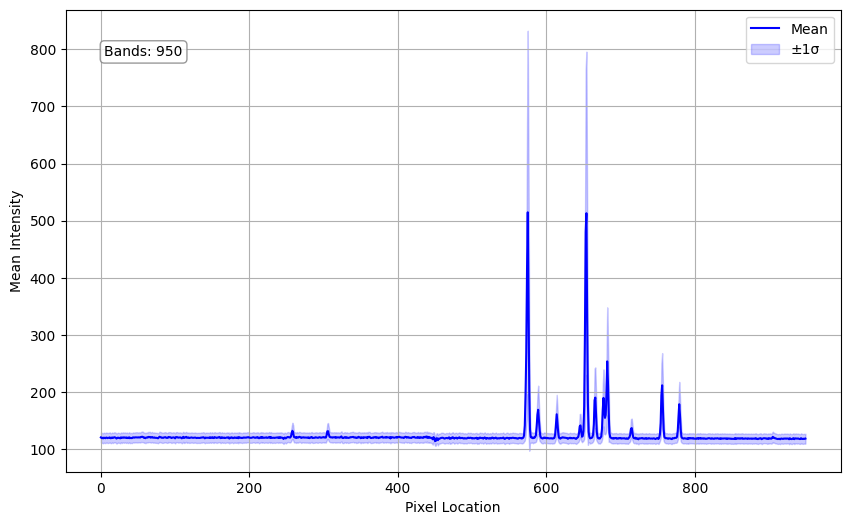

(950,)


In [35]:
# Plot the mean intensity
mean_intensities = plot_mean_spectrum(image=image)
print(mean_intensities.shape)

In [36]:
peak_indices = [
    575,
    589,
    614,
    646,
    654,
    666,
    682,
    ]
fwhm1 = compute_fwhm(mean_intensities, peak_indices)
print(fwhm1)

[2.9482741289332353, 2.9206749538777785, 2.5551038114327866, 2.7827986086632563, 2.992725204561907, 2.842717082888157, 2.853531958878648]


In [27]:
peak_indices = [
       9,
    62,
    241,
    ]
fwhm2 = compute_fwhm(mean_intensities, peak_indices)
print(fwhm2)

[2.73697032833733, 2.801882914179771, 2.842573746777731]


In [31]:
peak_indices = [
       672,
    680,
    699,
    ]
fwhm3 = compute_fwhm(mean_intensities, peak_indices)
print(fwhm3)

[2.9839984526656735, 2.8856216247249904, 2.5618197863324212]


In [38]:
fwhm = fwhm1 + fwhm2 + fwhm3
print(np.mean(fwhm))
print(np.std(fwhm))

2.823745584788745
0.13445792791365735


In [ ]:
# Find the spectral peaks
peak_info = find_spectral_peaks(spectrum=mean_intensities, wavelengths=wavelengths)
for info in peak_info:
    print(f"{info}: {peak_info[info]}")

In [ ]:
# # Perform spectral calibration
Kr = {
    575: 760.15,
    589: 768.52,
    614: 785.48,
    646: 805.95,
    654: 811.29,
    666: 819.01,
    677: 826.32,
    682: 829.81,
}
Xe = {
    672: 823.16,
    680: 828.01,
    699: 840.92,
}
Hg = {
    9:404.66,
    62: 434.75,
    241: 546.07,
    290: 576.96,
    293: 579.07,
}


# Create the calibration
results = calibrate_spectral_bands_multi(
    sources={"Kr": Kr, "Xe": Xe, "Hg": Hg},
    total_bands=None,              # infer from max observed band
    polynomial_order=1,
    save_path="../figures/spectral_calibration.svg",
    annotate=False,
    show=True,
    colors={"Kr": "tab:red", "Xe": "tab:green", "Hg": "tab:blue"},  # optional
)

# Compare the two calibrations
# mark_bands = band_numbers + [0, 232]
# compare_wavelength_calibrations(
#     wavelengths, calibration["calibrated_wavelengths"], mark_bands
# )